In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score
)

## Загрузка данных 

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train_df = pd.read_csv('../data/processed/y_train.csv')
y_test_df  = pd.read_csv('../data/processed/y_test.csv')

# Берём ТОЛЬКО колонку Class (или последнюю)
if 'Class' in y_train_df.columns:
    y_train = y_train_df['Class'].astype(int).values
    y_test  = y_test_df['Class'].astype(int).values
else:
    # берём последнюю колонку, на случай если индекс сохранился
    y_train = y_train_df.iloc[:, -1].astype(int).values
    y_test  = y_test_df.iloc[:, -1].astype(int).values

print("y_train:", np.unique(y_train, return_counts=True))
print("y_test :", np.unique(y_test,  return_counts=True))
print("dtype  :", y_train.dtype)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Фрод в train: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Фрод в test:  {y_test.sum()} ({y_test.mean()*100:.4f}%)")

y_train: (array([0, 1]), array([226602,    378]))
y_test : (array([0, 1]), array([56651,    95]))
dtype  : int64
X_train: (226980, 30), X_test: (56746, 30)
Фрод в train: 378 (0.1665%)
Фрод в test:  95 (0.1674%)


## Загрузка baseline LogReg

In [3]:
logreg = joblib.load('../models/logreg_baseline.pkl')
print(logreg)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


## RandomForest

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       n_jobs=-1, random_state=42)

## LightGBM is_unbalance=True

In [12]:
from sklearn.model_selection import train_test_split


X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,           
    stratify=y_train,
    random_state=42
)

print(f"Train: {X_tr.shape}, фрод: {y_tr.sum()}")
print(f"Val:   {X_val.shape}, фрод: {y_val.sum()}")

lgbm = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.02,        
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    importance_type='gain',
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
)
print(f"LGBM (is_unbalance) best_iteration: {lgbm.best_iteration_}")
print(f"LGBM (is_unbalance) best_score: {lgbm.best_score_['valid_0']['average_precision']:.4f}")

Train: (181584, 30), фрод: 302
Val:   (45396, 30), фрод: 76
LGBM (is_unbalance) best_iteration: 211
LGBM (is_unbalance) best_score: 0.8780


## LightGBM scale_pos_weight

In [13]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

lgbm_spw = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=123,           
    n_jobs=-1,
    verbose=-1
)

lgbm_spw.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric='average_precision',
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
)
print(f"LGBM (spw) best_iteration: {lgbm_spw.best_iteration_}")
print(f"LGBM (spw) best_score: {lgbm_spw.best_score_['valid_0']['average_precision']:.4f}")

scale_pos_weight = 600.27
LGBM (spw) best_iteration: 394
LGBM (spw) best_score: 0.8674


## Расчет метрик

In [14]:
AVG_FRAUD_AMOUNT = 122.0
COST_FP = 5.0

def evaluate_model(model, X_test, y_test, name):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    business_loss = fn * AVG_FRAUD_AMOUNT + fp * COST_FP
    
    return {
        'Модель': name,
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'PR-AUC': average_precision_score(y_test, y_proba),
        'Recall@0.5': recall_score(y_test, y_pred),
        'Precision@0.5': precision_score(y_test, y_pred, zero_division=0),
        'F1@0.5': f1_score(y_test, y_pred),
        'FN': int(fn),
        'FP': int(fp),
        'Business loss': business_loss,
        '_y_proba': y_proba,
        '_y_pred': y_pred
    }

results = [
    evaluate_model(logreg,   X_test, y_test, 'LogReg (balanced)'),
    evaluate_model(rf,       X_test, y_test, 'Random Forest'),
    evaluate_model(lgbm,     X_test, y_test, 'LightGBM (is_unbalance)'),
    evaluate_model(lgbm_spw, X_test, y_test, 'LightGBM (scale_pos_weight)'),
]

results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
print("="*100)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*100)
print(results_df.to_string(index=False, float_format='%.4f'))

СРАВНЕНИЕ МОДЕЛЕЙ
                     Модель  ROC-AUC  PR-AUC  Recall@0.5  Precision@0.5  F1@0.5  FN   FP  Business loss
          LogReg (balanced)   0.9625  0.6740      0.8737         0.0549  0.1033  12 1429      8609.0000
              Random Forest   0.9612  0.7668      0.7368         0.8861  0.8046  25    9      3095.0000
    LightGBM (is_unbalance)   0.9278  0.7926      0.7789         0.7551  0.7668  21   24      2682.0000
LightGBM (scale_pos_weight)   0.9399  0.7910      0.7684         0.8488  0.8066  22   13      2749.0000


## ROC и PR кривые

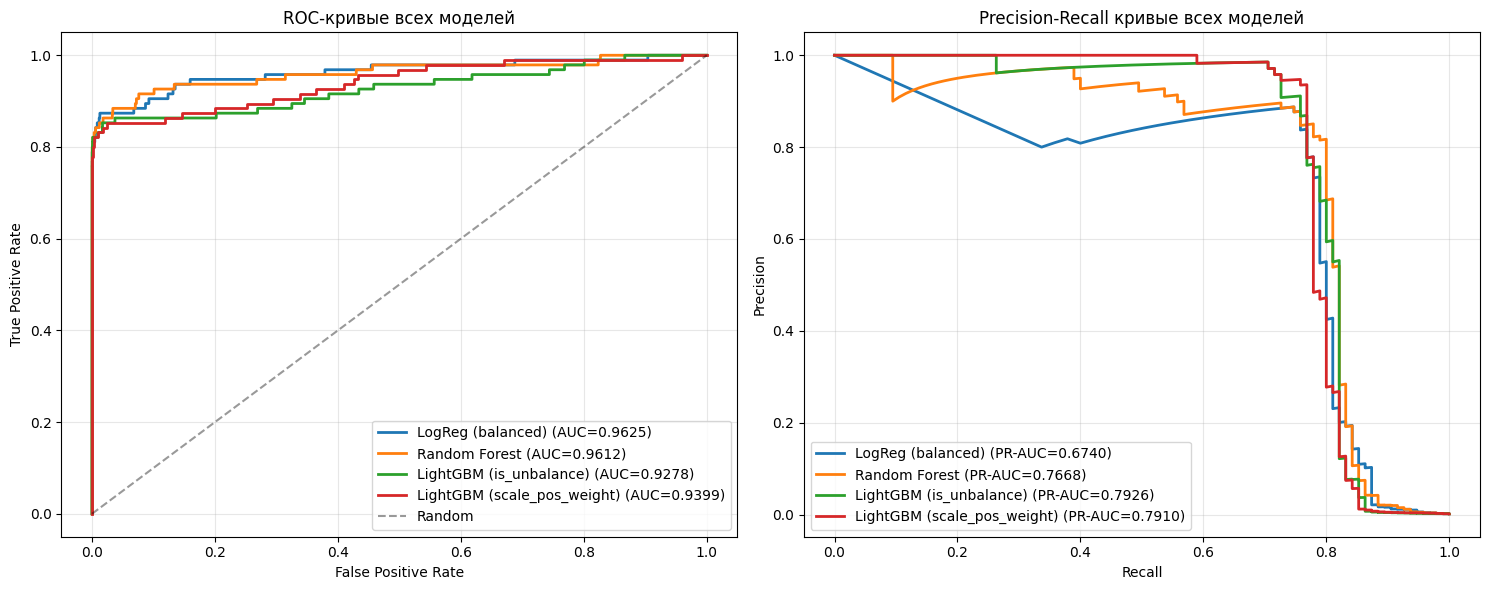

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for r, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['_y_proba'])
    axes[0].plot(fpr, tpr, label=f"{r['Модель']} (AUC={r['ROC-AUC']:.4f})", linewidth=2, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривые всех моделей')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

for r, color in zip(results, colors):
    prec, rec, _ = precision_recall_curve(y_test, r['_y_proba'])
    axes[1].plot(rec, prec, label=f"{r['Модель']} (PR-AUC={r['PR-AUC']:.4f})", linewidth=2, color=color)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall кривые всех моделей')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Confusion matrices

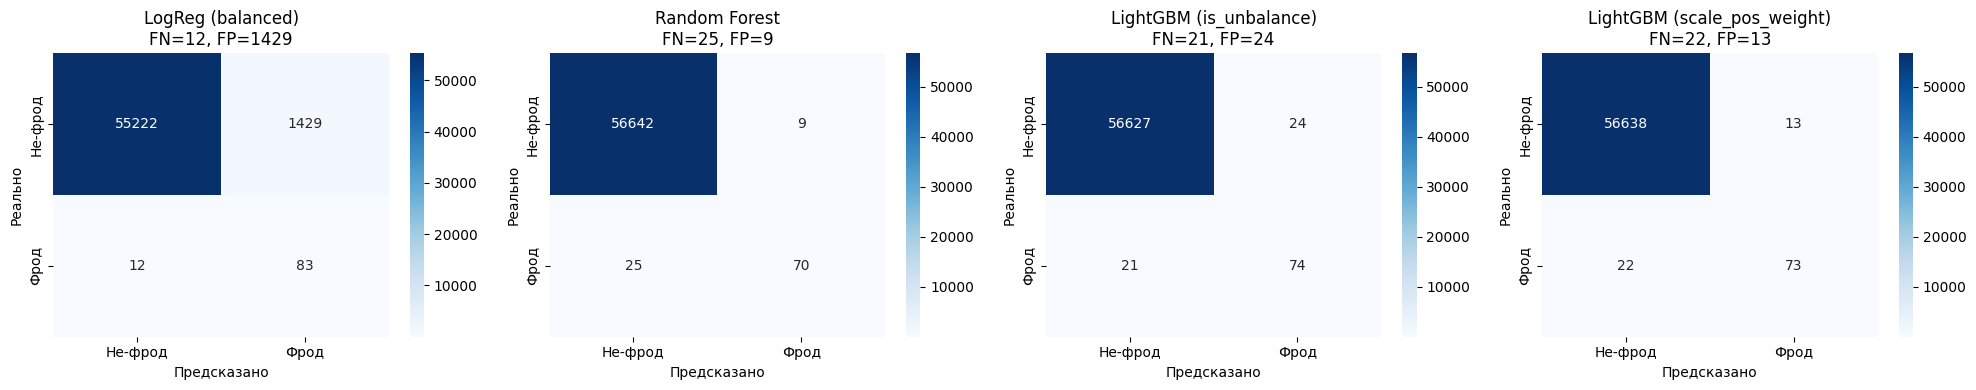

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Не-фрод', 'Фрод'], yticklabels=['Не-фрод', 'Фрод'])
    ax.set_title(f"{r['Модель']}\nFN={r['FN']}, FP={r['FP']}")
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Реально')
plt.tight_layout()
plt.show()

## Лучшая модель

🏆 Лучшая модель по PR-AUC: LightGBM (is_unbalance) (PR-AUC = 0.7926)


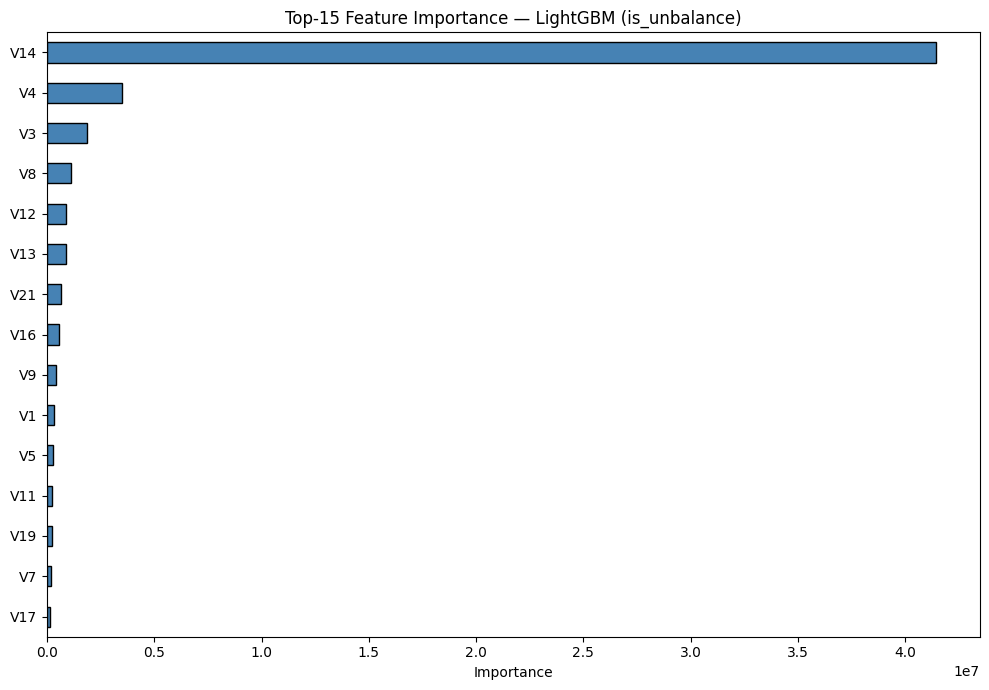


Top-15 признаков:
V14    4.142080e+07
V4     3.503029e+06
V3     1.874198e+06
V8     1.130832e+06
V12    8.812841e+05
V13    8.649062e+05
V21    6.509303e+05
V16    5.489077e+05
V9     4.313150e+05
V1     3.366540e+05
V5     2.727496e+05
V11    2.236449e+05
V19    2.158757e+05
V7     1.808225e+05
V17    1.561886e+05
dtype: float64


In [17]:
best_idx = max(range(len(results)), key=lambda i: results[i]['PR-AUC'])
best_result = results[best_idx]
print(f"🏆 Лучшая модель по PR-AUC: {best_result['Модель']} (PR-AUC = {best_result['PR-AUC']:.4f})")

models_map = {
    'LogReg (balanced)': logreg,
    'Random Forest': rf,
    'LightGBM (is_unbalance)': lgbm,
    'LightGBM (scale_pos_weight)': lgbm_spw,
}
best_model = models_map[best_result['Модель']]

tree_results = [r for r in results if r['Модель'] != 'LogReg (balanced)']
best_tree_idx = max(range(len(tree_results)), key=lambda i: tree_results[i]['PR-AUC'])
best_tree_name = tree_results[best_tree_idx]['Модель']
best_tree_model = models_map[best_tree_name]

importances = pd.Series(best_tree_model.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top15.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title(f'Top-15 Feature Importance — {best_tree_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop-15 признаков:")
print(top15)

## Бизнес метрика

In [18]:
print("="*80)
print("БИЗНЕС-УБЫТКИ ВСЕХ МОДЕЛЕЙ (порог 0.5)")
print("="*80)
print(f"FN-стоимость: ${AVG_FRAUD_AMOUNT}/шт, FP-стоимость: ${COST_FP}/шт\n")

biz_df = results_df[['Модель', 'FN', 'FP', 'Business loss']].copy()
biz_df['Business loss'] = biz_df['Business loss'].apply(lambda x: f"${x:,.2f}")
print(biz_df.to_string(index=False))

baseline_loss = results[0]['Business loss']
print(f"\nЭкономия лучшей модели vs LogReg: ${baseline_loss - best_result['Business loss']:,.2f}")

БИЗНЕС-УБЫТКИ ВСЕХ МОДЕЛЕЙ (порог 0.5)
FN-стоимость: $122.0/шт, FP-стоимость: $5.0/шт

                     Модель  FN   FP Business loss
          LogReg (balanced)  12 1429     $8,609.00
              Random Forest  25    9     $3,095.00
    LightGBM (is_unbalance)  21   24     $2,682.00
LightGBM (scale_pos_weight)  22   13     $2,749.00

Экономия лучшей модели vs LogReg: $5,927.00


## Сохранение модели

In [19]:
joblib.dump(best_model, '../models/best_tree_model.pkl')

summary = {
    'best_model_name': best_result['Модель'],
    'roc_auc': float(best_result['ROC-AUC']),
    'pr_auc': float(best_result['PR-AUC']),
    'recall': float(best_result['Recall@0.5']),
    'precision': float(best_result['Precision@0.5']),
    'f1': float(best_result['F1@0.5']),
    'fn': int(best_result['FN']),
    'fp': int(best_result['FP']),
    'business_loss': float(best_result['Business loss']),
    'pr_auc_improvement_vs_logreg_pct': float(
        (best_result['PR-AUC'] - results[0]['PR-AUC']) / results[0]['PR-AUC'] * 100
    ),
    'business_loss_savings_vs_logreg': float(
        results[0]['Business loss'] - best_result['Business loss']
    )
}

with open('../models/tree_models_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ Сохранено: ../models/best_tree_model.pkl")
print("✅ Сохранено: ../models/tree_models_metrics.json")
print(json.dumps(summary, indent=2, ensure_ascii=False))

✅ Сохранено: ../models/best_tree_model.pkl
✅ Сохранено: ../models/tree_models_metrics.json
{
  "best_model_name": "LightGBM (is_unbalance)",
  "roc_auc": 0.9277846166138191,
  "pr_auc": 0.792604163193425,
  "recall": 0.7789473684210526,
  "precision": 0.7551020408163265,
  "f1": 0.7668393782383419,
  "fn": 21,
  "fp": 24,
  "business_loss": 2682.0,
  "pr_auc_improvement_vs_logreg_pct": 17.59684674519282,
  "business_loss_savings_vs_logreg": 5927.0
}


## 📌 Выводы

### 1. Лучшая модель по PR-AUC
**LightGBM с `is_unbalance=True`** показал лучший результат:
- PR-AUC = **0.7926** (на 17.6% выше LogReg baseline)
- Минимальный бизнес-убыток: **$2,682** (экономия $5,927 vs LogReg)
- Best iteration = 211 (early stopping сработал корректно)

### 2. Улучшение vs LogReg baseline
| Метрика | LogReg | LightGBM | Δ |
|---|---|---|---|
| PR-AUC | 0.6740 | 0.7926 | **+17.6%** |
| FP | 1429 | 24 | **−98.3%** |
| Business loss | $8,609 | $2,682 | **−$5,927 (−68.8%)** |

Главное достижение — резкое падение FP при сравнимом Recall.

### 3. Уменьшение FN при разумном FP
- LogReg: FN=12, FP=1429 — ловит фрод, но затопляет систему ложными срабатываниями.
- LightGBM: FN=21, FP=24 — небольшое увеличение FN компенсируется **в 60 раз** меньшим числом FP.
- Random Forest: FN=25, FP=9 — самый «осторожный», но пропускает на 4 фрода больше.

С точки зрения бизнеса (FP-стоимость = $5, FN-стоимость = $122) выигрывает LightGBM.

### 4. Feature Importance
Топ-5 признаков по информативности (gain):
1. **V14** — доминирует с огромным отрывом (4.1e+07)
2. **V4** — второй по важности (3.5e+06)
3. **V3** — 1.9e+06
4. **V8** — 1.1e+06
5. **V12** — 8.8e+05

Признаки **V14, V12, V4, V3** совпадают с EDA-топом признаков, наиболее коррелирующих с целевой переменной — модель самостоятельно «нашла» те же сигналы, которые мы выделили на этапе анализа данных.

### 5. Целевой ориентир
PR-AUC = 0.85 пока не достигнут (0.79 на тесте), но мы уже близко. В следующем задании **Optuna-тюнинг** должен дать +0.05–0.07 PR-AUC за счёт настройки `num_leaves`, `min_child_samples`, `learning_rate`, `reg_alpha/lambda`.

### 6. Кандидат в следующий этап
**LightGBM (is_unbalance=True)** — лучший по PR-AUC и бизнес-метрике, быстрее RF, поддерживает early stopping (важно для сотен Optuna-trials).